# CRISPR and Perturb-seq (pooled single-cell CRISPR screen).

Originall CRISPR is the bacteria immune system.

It is modified as a gene-editing technology to study gene function by altering DNA sequences.
Perturb-seq combines CRISPR with single-cell RNA sequencing to analyze how hundreds of genetic edits change gene expression simultaneously.   
Mainly three types/modes: gene knockout, interference, activation.

Three major CRISPR perturbation modes used in Perturb-seq.   
They are different ways of perturbing gene function before doing single-cell RNA-seq.
Method      Cas_protein        What-happens?                   Effect_gene_expression      Typical_use    
CRISPR-KO
(knockout)   Cas9_nuclease  Cuts DNA->indels->disrupts_gene    near loss-of-function     Identify genes required for a phenotype
CRISPRi(interference)      dCas9-KRAB     Binds promoter and recruits repression machinery reduce_transcription_without_DNA_cutting  Most_common_for_genome_scale_Perturb-seq
CRISPRa(activation) dCas9-VPR/SAM  Binds_promoter_and_recruits_activators  Increase_transcription  Study gene overexpression effects

Perturb-seq sequences the whole single-cell transcriptome, not just the targeted gene.

After obtaining the sequencing reads, it will go through the Cell Ranger (or STARsolo) to obtain gene expression matrix (cell by gene), and guide alignment data by providing:
`libraries.csv` → tells Cell Ranger which FASTQs are Gene Expression and which are CRISPR Guide Capture.
`feature_ref.csv` → tells Cell Ranger the expected sgRNA sequences and their target genes.

Cell Ranger then processes the two libraries separately and merges them by cell barcode, producing a single dataset that contains both the whole-transcriptome expression profile and the perturbation identity for each cell.


## Workflow of Perturb-seq analysis
Step1: Read Cell Ranger Data

Step2: Assign guideRNAs

Step3: Quality Control (QC) & Preprocessing (Both Modalities)
    RNA Modality Filtering: Remove low-quality cells based on high mitochondrial gene percentages, low UMI counts, or low numbers of detected genes.  
    Guide Modality Filtering: Filter out cells that were assigned zero guides (untransduced cells) or cells that received too many guides (multiplets), depending on your experimental MOI (Multiplicity of Infection).  
    Normalization & Scaling: Log-normalize the RNA counts to account for sequencing depth differences across cells.

Step4: Dimension Reduction & Embedding
    Highly Variable Gene (HVG) Selection: Identify genes that vary significantly across the cell population, explicitly excluding the guide RNAs and selection markers to prevent artificial clustering.  
    PCA & UMAP/t-SNE: Run Principal Component Analysis (PCA) on the HVGs and project the data into a 2D space (UMAP or t-SNE) to visually inspect if your perturbations alter the global cell states or cause distinct clustering.

Step5: Defining Controls & Reference States
    Identify Non-Targeting Controls (NTCs): Group the cells that were assigned control guides (non-targeting or scramble sequences). These cells represent the unperturbed, baseline "wild-type" state of your biological system.Quality Check Controls: Ensure NTC cells are evenly distributed across your clusters and do not form isolated, artificial groupings.

Step6: Differential Expression (DE) & Perturbation Scoring
    In silico Knockout/Activation Verification: Verify that the perturbation worked. For example, if Guide_A targets Gene_X, check if cells with Guide_A show a massive drop in Gene_X expression compared to NTC cells.  
    Differential Expression Testing: Run DE analyses (using tools like Scanpy, Seurat, or specialized tools like SCEPTRE or MIMOSCA) comparing each specific guide group against the NTC baseline group to find downstream responder genes.  
    Calculate a Perturbation Score: For complex screens, calculate a numeric metric (like E-statistics or Mixscape scores) to quantify the strength of the phenotype for each cell, separating successful knockouts from "escapers" (cells that have the guide but didn't undergo successful gene editing).

Step7: Downstream Functional Genomics & Modeling
    Gene Set Enrichment Analysis (GSEA): Run pathway analysis on the differentially expressed genes to discover which biological pathways (e.g., apoptosis, cell cycle) were altered by each guide.  
    Perturbation Co-functional Networks: Cluster your guides based on the similarity of their downstream transcriptional profiles. If Guide_Y and Guide_Z yield identical downstream expression signatures, it indicates those two target genes operate in the same genetic pathway or protein complex.



Perturb-seq technical noise/background includes:
ambient RNA,
with guide but fail to edit genes. These cells are called escapers.


In [12]:
import jax.numpy as jnp
import numpy as np
import pandas as pd
import pertpy as pt
import scanpy as sc
import scipy
from jax import random

In [13]:
def generate_toy_data(n_guides: int = 2, n_cells_per_group: int = 50):
    dats = []
    for i in range(n_guides):
        key = random.PRNGKey(i)
        key1, key2, key3 = random.split(key, num=3)

        # Negative first
        poisson_data = random.poisson(key1, lam=0.1, shape=(n_cells_per_group * i,)).astype(jnp.float32)
        if i == 1:  # Add a double positive population for the second guide
            poisson_data = random.normal(key3, shape=(n_cells_per_group,)) * 1.0 + 3
            poisson_data = poisson_data.clip(0.0, None)

        # Positive
        gaussian_data = random.normal(key2, shape=(n_cells_per_group,)) * 1.0 + 3
        gaussian_data = gaussian_data.clip(0.0, None)

        # Negative second
        poisson_data_ = random.poisson(key1, lam=0.1, shape=(n_cells_per_group * (n_guides - i - 1),)).astype(
            jnp.float32
        )

        # The count vector for one guide is the concatenation of the negative and positive populations
        guide_data = jnp.hstack([poisson_data, gaussian_data, poisson_data_])
        dats.append(guide_data)
    guide_counts = np.array(jnp.vstack(dats)).T

    # Combine Poisson and Gaussian data into one dataset
    adata = sc.AnnData(
        guide_counts,
        obs=pd.DataFrame(index=[f"cell{i + 1}" for i in range(guide_counts.shape[0])]),
        var=pd.DataFrame(index=[f"guide{i + 1}" for i in range(guide_counts.shape[1])]),
    )
    adata.obs["ground_truth"] = ["guide" + str(i + 1) for i in range(n_guides) for _ in range(n_cells_per_group)]
    col = adata.obs["ground_truth"].copy()
    col.iloc[:n_cells_per_group] = "guide1+guide2"
    adata.obs["ground_truth"] = col
    return adata

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


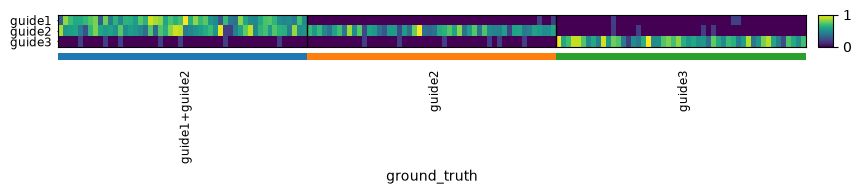

In [14]:
adata = generate_toy_data(n_guides=3, n_cells_per_group=50)
sc.pl.heatmap(
    adata, groupby="ground_truth", cmap="viridis", standard_scale="var", var_names=adata.var_names, swap_axes=True
)

In [15]:
adata

AnnData object with n_obs × n_vars = 150 × 3
    obs: 'ground_truth'
    uns: 'ground_truth_colors'
    layers: None (.X)

In [16]:
adata.to_df().stack().reset_index().rename(columns={"level_0": "cell", "level_1": "guide", 0: "expression"})

import seaborn as sns
from matplotlib import pyplot as plt



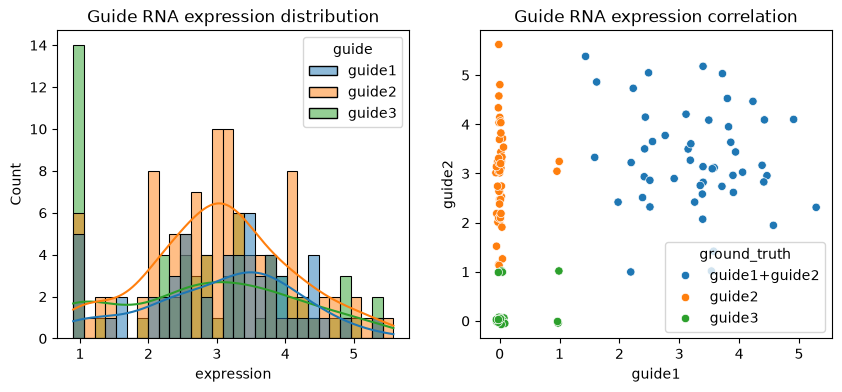

In [17]:
df = adata.to_df().stack().reset_index().rename(columns={"level_0": "cell", "level_1": "guide", 0: "expression"})
import seaborn as sns
from matplotlib import pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
df = df[df.expression > 0]
sns.histplot(df, x="expression", hue="guide", bins=30, kde=True, ax=axs[0])
axs[0].set_title("Guide RNA expression distribution")
df = adata.to_df()
df = np.random.default_rng().normal(0, 0.03, df.shape) + df  # Add jitter
sns.scatterplot(data=df, x="guide1", y="guide2", hue=adata.obs["ground_truth"], ax=axs[1])
axs[1].set_title("Guide RNA expression correlation")
plt.show()

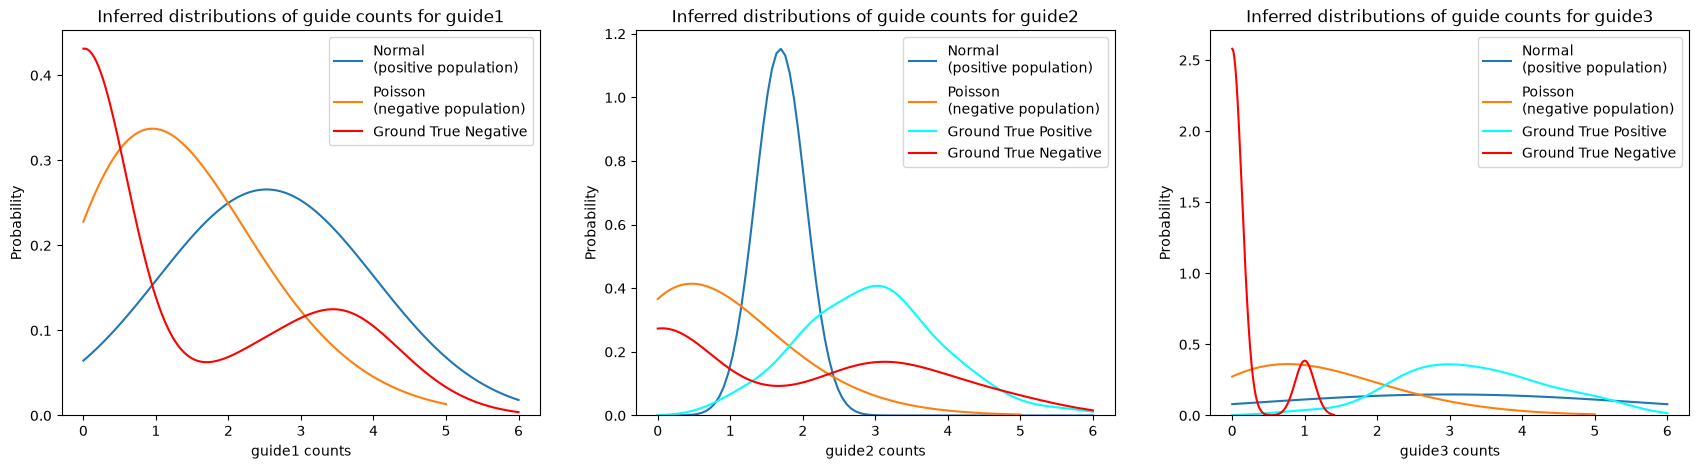

In [18]:
# Mixture model
ga = pt.pp.GuideAssignment()
ga.assign_mixture_model(adata, assigned_guides_key="assigned_guide_mixture_model")

import numpyro.distributions as dist

# plot probability distributions of model
n_guides = len(adata.var_names)
guides = adata.var_names
fig, axs = plt.subplots(1, n_guides, figsize=(7 * n_guides, 5))
for ax, guide in zip(axs, guides):
    # plot gaussian distribution
    x = np.linspace(0, 6, 100)
    y = dist.Normal(
        adata.var.loc[guide, "gaussian_mean"],
        adata.var.loc[guide, "gaussian_std"],
    ).log_prob(x)
    ax.plot(x, np.exp(y), label="Normal\n(positive population)")
    # plot poisson distribution
    x = np.linspace(0, 5, 100)
    y = dist.Poisson(adata.var.loc[guide, "poisson_rate"]).log_prob(x)
    ax.plot(x, np.exp(y), label="Poisson\n(negative population)")

    # Plot ground truth empirical distribution
    sns.kdeplot(
        np.ravel(adata[adata.obs.ground_truth == guide, guide].X),
        color="cyan",
        label="Ground True Positive",
        ax=ax,
        clip=(0, 6),
    )
    sns.kdeplot(
        np.ravel(adata[adata.obs.ground_truth != guide, guide].X),
        color="red",
        label="Ground True Negative",
        ax=ax,
        clip=(0, 6),
    )

    ax.set_xlabel(f"{guide} counts")
    ax.set_ylabel("Probability")
    ax.legend()
    ax.set_title(f"Inferred distributions of guide counts for {guide}")

plt.show()


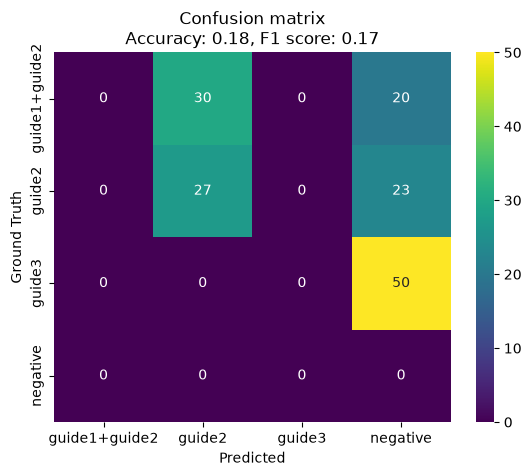

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

accuracy = accuracy_score(adata.obs["ground_truth"], adata.obs["assigned_guide_mixture_model"])
f1 = f1_score(adata.obs["ground_truth"], adata.obs["assigned_guide_mixture_model"], average="weighted")

all_labels = np.union1d(adata.obs["ground_truth"].unique(), np.unique(adata.obs["assigned_guide_mixture_model"]))

cm = confusion_matrix(adata.obs["ground_truth"], adata.obs["assigned_guide_mixture_model"], labels=all_labels)
cm_df = pd.DataFrame(cm, index=all_labels, columns=all_labels)

ax = sns.heatmap(cm_df, annot=True, fmt="d", cmap="viridis")
ax.set_ylabel("Ground Truth")
ax.set_xlabel("Predicted")
plt.title(f"Confusion matrix\nAccuracy: {np.round(accuracy, 2)}, F1 score: {np.round(f1, 2)}")
plt.show()

# Deal with real perturb-seq data

In [20]:
mdata = pt.dt.papalexi_2021()
mdata

/home/limin/.conda/envs/pertpy_v11_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1471: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=0, join_common=join_common)


MuData object with n_obs × n_vars = 20729 × 18776
  obs:	'MULTI_ID', 'HTO_classification', 'guide_ID', 'gene_target', 'NT', 'perturbation', 'replicate', 'S.Score', 'G2M.Score', 'phase'
  var:	'name'
  4 modalities
    rna:	20729 × 18649
      obs:	'nCount_RNA', 'nFeature_RNA', 'percent.mito'
      var:	'name'
      layers:	None
    adt:	20729 × 4
      obs:	'nCount_ADT', 'nFeature_ADT'
      var:	'name'
      layers:	None
    hto:	20729 × 12
      obs:	'nCount_HTO', 'nFeature_HTO', 'technique'
      var:	'name'
      layers:	None
    gdo:	20729 × 111
      obs:	'nCount_GDO'
      var:	'name'
      layers:	None

In [21]:
# load the benchmark CITE-seq + Perturb-seq published by Papalexi et al. (Nature Genetics, 2021).
mdata = pt.dt.papalexi_2021()

# It pulls out the raw count matrix (.X) of the Guide Detection Oligo (gdo) modality, converts it from a memory-efficient sparse array to a standard dense array (.toarray()), subtracts 1 from every single value, and then converts it back into a compressed sparse row matrix (csr_matrix).
# When Cell Ranger generates CRISPR feature-barcode matrices, it frequently incorporates an artificial floor or pseudocount offset of +1 in its internal tracking logic to prevent computational zeros. Left uncorrected, this implies that every single cell contains every single guide at a baseline level of 1 count. Subtracting 1 returns true zero-expression dropouts to 0.
mdata.mod['gdo'].X = scipy.sparse.csr_matrix(mdata.mod['gdo'].X.toarray() -1)

# Pushing observations to Modalities
""" 
Updates the internal metadata columns. It takes the specific cell assignment metric named "guide_ID" (which lives at the global mdata.obs metadata layer, flagged with the prefix gdo:) and securely "pushes" or copies that mapping down into the local annotation slot (.obs) of the specific "gdo" modality block.
Why this is needed: MuData uses a parent-child relationship model. Pushing ensuring that downstream analysis pipelines running natively inside the child gdo slice can immediately see which specific guide identity was assigned to which cell barcode without having to query the global multi-omic parent layer.

"""
# The gdo: prefix specifies the target modality (or data layer) inside your MuData object.
mdata.push_obs(columns=["gdo:guide_ID"], mods="gdo") # add guide_ID column in mode:gdo
 
gdo = mdata.mod["gdo"]
gdo

/home/limin/.conda/envs/pertpy_v11_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1471: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=0, join_common=join_common)


AnnData object with n_obs × n_vars = 20729 × 111
    obs: 'nCount_GDO', 'guide_ID'
    var: 'name'
    layers: None (.X)

In [22]:
# Now we only work on the gdo data. Save the original count values and transform the data
gdo.layers["counts"] = gdo.X.copy()
sc.pp.log1p(gdo)
gdo


AnnData object with n_obs × n_vars = 20729 × 111
    obs: 'nCount_GDO', 'guide_ID'
    var: 'name'
    uns: 'log1p'
    layers: None (.X), 'counts'

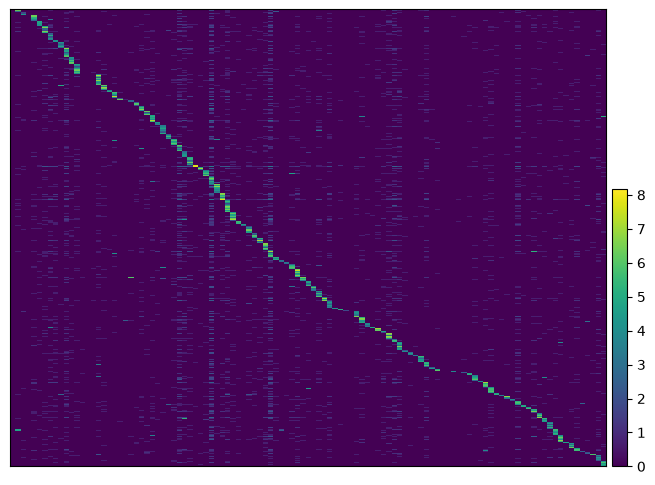

In [23]:
# Visualize the expression of guides per cells.
ga = pt.pp.GuideAssignment()
ga.plot_heatmap(gdo, key_to_save_order="plot_order") # add 'plot_order' column to obs.



In [24]:
# Assign to the guide RNA with the highest detection:
ga = pt.pp.GuideAssignment()
ga.assign_to_max_guide(gdo, assignment_threshold=5, layer="counts") #


# compare the guide assignment results with Mixscape results, which is the industry standard for guide assignment.
sum(gdo.obs["assigned_guide"] != gdo.obs["guide_ID"]) # 0 means fully match of the two methods, indicating good guide assignment.


0

/home/limin/.conda/envs/pertpy_v11_env/lib/python3.12/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


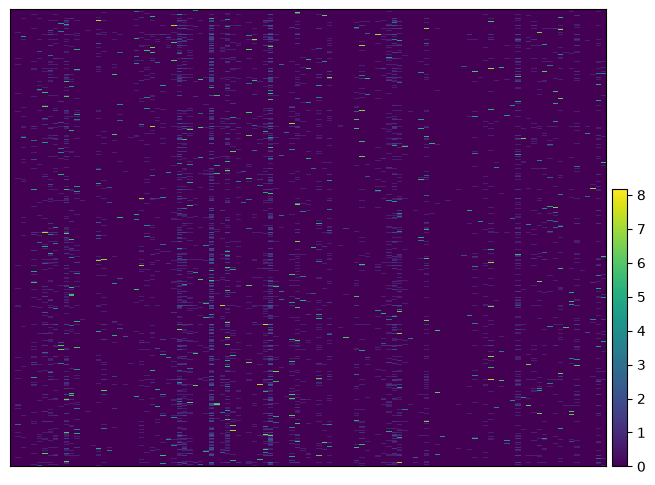

In [25]:
ga.plot_heatmap(gdo, order_by="plot_order")

In [26]:
## Quantifying Perturbation efficacy in pooled CRISPR screens

In [27]:
#!pip install muon

In [28]:
#!pip install muon
import muon as mu
import pertpy as pt
import scanpy as sc

In [29]:
mdata = pt.dt.papalexi_2021()
gene_target_data = mdata.obs["gene_target"].copy()
mdata.push_obs(columns=["replicate", "phase", "perturbation", "NT"], mods=["rna"])
mdata["rna"].obs["gene_target"] = gene_target_data
mdata["adt"].obs["gene_target"] = gene_target_data
mdata

/home/limin/.conda/envs/pertpy_v11_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1471: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=0, join_common=join_common)


MuData object with n_obs × n_vars = 20729 × 18776
  obs:	'MULTI_ID', 'HTO_classification', 'guide_ID', 'gene_target', 'NT', 'perturbation', 'replicate', 'S.Score', 'G2M.Score', 'phase'
  var:	'name'
  4 modalities
    rna:	20729 × 18649
      obs:	'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'NT', 'perturbation', 'phase', 'replicate', 'gene_target'
      var:	'name'
      layers:	None
    adt:	20729 × 4
      obs:	'nCount_ADT', 'nFeature_ADT', 'gene_target'
      var:	'name'
      layers:	None
    hto:	20729 × 12
      obs:	'nCount_HTO', 'nFeature_HTO', 'technique'
      var:	'name'
      layers:	None
    gdo:	20729 × 111
      obs:	'nCount_GDO'
      var:	'name'
      layers:	None

## Preprocessing both RNA and protein follow standard Scanpy workflow.

In [30]:

# RNA - normalization, find highly variable genes
sc.pp.normalize_total(mdata["rna"])
sc.pp.log1p(mdata["rna"])
sc.pp.highly_variable_genes(mdata["rna"], subset=True)

# protein - normalization across cells (axis=1)
mu.prot.pp.clr(mdata["adt"], axis=1)



/home/limin/.conda/envs/pertpy_v11_env/lib/python3.12/site-packages/muon/_prot/preproc.py:272: UserWarning: adata.X is sparse but not in CSR format. CSR format required for `axis=1`. Converting to CSR.
  warn(


## RNA-based clustering  

The UMAP plot shows that the clustering is driven by confounding sources of variation: cell cycle phases and replicate IDs.  

This confounding issue is fixed in next step.



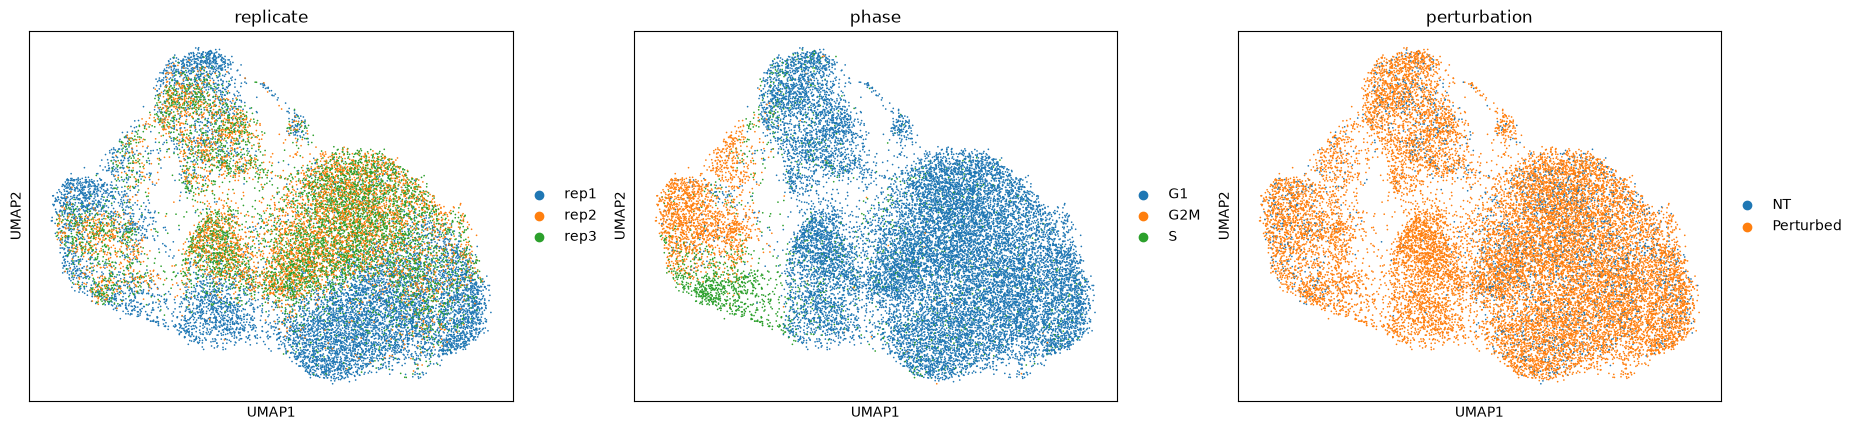

In [31]:
sc.pp.pca(mdata["rna"])

sc.pp.neighbors(mdata["rna"], metric="cosine")
sc.tl.umap(mdata["rna"])
sc.pl.umap(mdata["rna"], color=["replicate", "phase", "perturbation"])



In [32]:
mdata

MuData object with n_obs × n_vars = 20729 × 18776
  obs:	'MULTI_ID', 'HTO_classification', 'guide_ID', 'gene_target', 'NT', 'perturbation', 'replicate', 'S.Score', 'G2M.Score', 'phase'
  var:	'name'
  4 modalities
    rna:	20729 × 1917
      obs:	'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'NT', 'perturbation', 'phase', 'replicate', 'gene_target'
      var:	'name', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'replicate_colors', 'phase_colors', 'perturbation_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	None
      obsp:	'distances', 'connectivities'
    adt:	20729 × 4
      obs:	'nCount_ADT', 'nFeature_ADT', 'gene_target'
      var:	'name'
      layers:	None
    hto:	20729 × 12
      obs:	'nCount_HTO', 'nFeature_HTO', 'technique'
      var:	'name'
      layers:	None
    gdo:	20729 × 111
      obs:	'nCount_GDO'
      var:	'name'
      layers:	None

The independent adata_pert part below is the visual proof that the input data is clean enough for ms.mixscape() wo work accurately. Because under the hood, mixscape() is running exactly the same code as the following adata_part did. The "Mixscape Assumptions" assumes that the variation in your gene expression layer (X_pert) is driven by the genetic pertubations, not by cell cycle or batch effects. 

`ms.perturbation_signature(mdata["rna"], ..., split_by="replicate")`
Inside that function, Mixscape loops through every single replicate independently. It finds the Non-Targeting (NT) control cells within that specific replicate and uses them to calculate a local baseline. It then subtracts that baseline from the perturbed cells. This step mathematically cancels out the replicate batch effect and the cell-cycle phase variance.

Therefore adata_pert part is just a quick verification of removing confounding varianles.   
Besides deal with confounding issue, Mixscape workflow (the mixture model classification) also identify "Escape" cells. In a Perturb-seq experiment, just because a cell receives a guide RNA (gRNA) does not mean the gene knockout actually worked. Many cells are "escapees"—they have the gRNA, but the protein was not successfully knocked down, so their phenotype remains wild-type (normal).


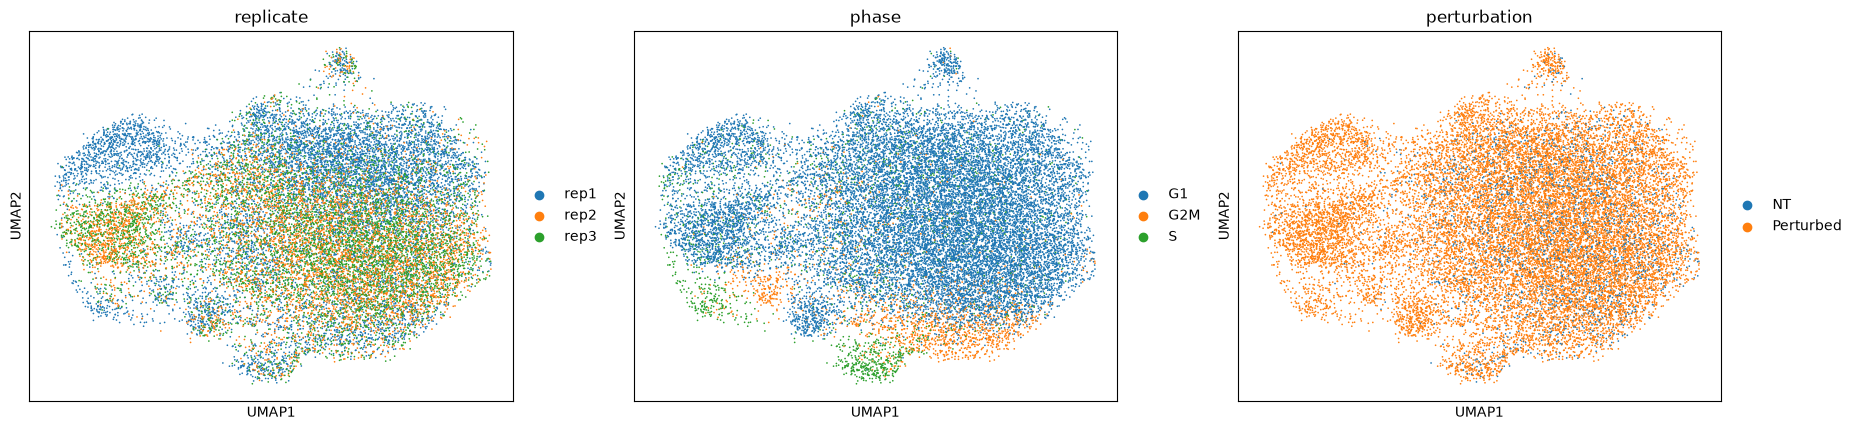

In [33]:
ms = pt.tl.Mixscape()
ms.perturbation_signature(mdata["rna"], pert_key="perturbation", control="NT",split_by="replicate")

adata_pert = mdata["rna"].copy()
adata_pert.X = adata_pert.layers["X_pert"]
sc.pp.pca(adata_pert)
sc.pp.neighbors(adata_pert, metric="cosine")
sc.tl.umap(adata_pert)
sc.pl.umap(adata_pert, color=["replicate", "phase", "perturbation"])




## Mixscape: classifying perturbed cells

By modelling the perturbation signature as a mixture of the non-targeting control distribution and a perturbed distribution, Mixscape assigns each targeted cell a binary label, perturbed (KO) or non-perturbed (NP).


In [34]:

# mu.write("my_processed_perturb_seq_data.h5mu", mdata)




In [35]:
mdata = mu.read("my_processed_perturb_seq_data.h5mu")

mdata

/home/limin/.conda/envs/pertpy_v11_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1471: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=0, join_common=join_common)


MuData object with n_obs × n_vars = 20729 × 2044
  obs:	'MULTI_ID', 'HTO_classification', 'guide_ID', 'gene_target', 'NT', 'perturbation', 'replicate', 'S.Score', 'G2M.Score', 'phase'
  var:	'name'
  4 modalities
    rna:	20729 × 1917
      obs:	'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'NT', 'perturbation', 'phase', 'replicate', 'gene_target', 'mixscape_class_p_ko', 'mixscape_class', 'mixscape_class_global'
      var:	'name', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'hvg', 'log1p', 'neighbors', 'pca', 'perturbation_colors', 'phase_colors', 'replicate_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'X_pert', None
      obsp:	'connectivities', 'distances'
    adt:	20729 × 4
      obs:	'nCount_ADT', 'nFeature_ADT', 'gene_target'
      var:	'name'
      layers:	None
    hto:	20729 × 12
      obs:	'nCount_HTO', 'nFeature_HTO', 'technique'
      var:	'name'
      layers:	None
    gdo:	20729 × 111
      obs:	'nCount_GDO'
      var:	'name'
      layers:	None

In [36]:
# """ 
# Numpy2.0
# scikit-learn(v1.6+)
# they have version complicated issue. The following code is the workaround.
# """

# import pertpy
# from pertpy.tools._mixscape import MixscapeGaussianMixture

# # Define a wrapper function that intercepts the 'xp' argument gracefully
# old_m_step = MixscapeGaussianMixture._m_step

# def patched_m_step(self, X, log_resp, xp=None, **kwargs):
#     # If scikit-learn passes 'xp', we safely consume it or pass it along if needed
#     return old_m_step(self, X, log_resp)

# # Apply the patch directly into the loaded module
# MixscapeGaussianMixture._m_step = patched_m_step


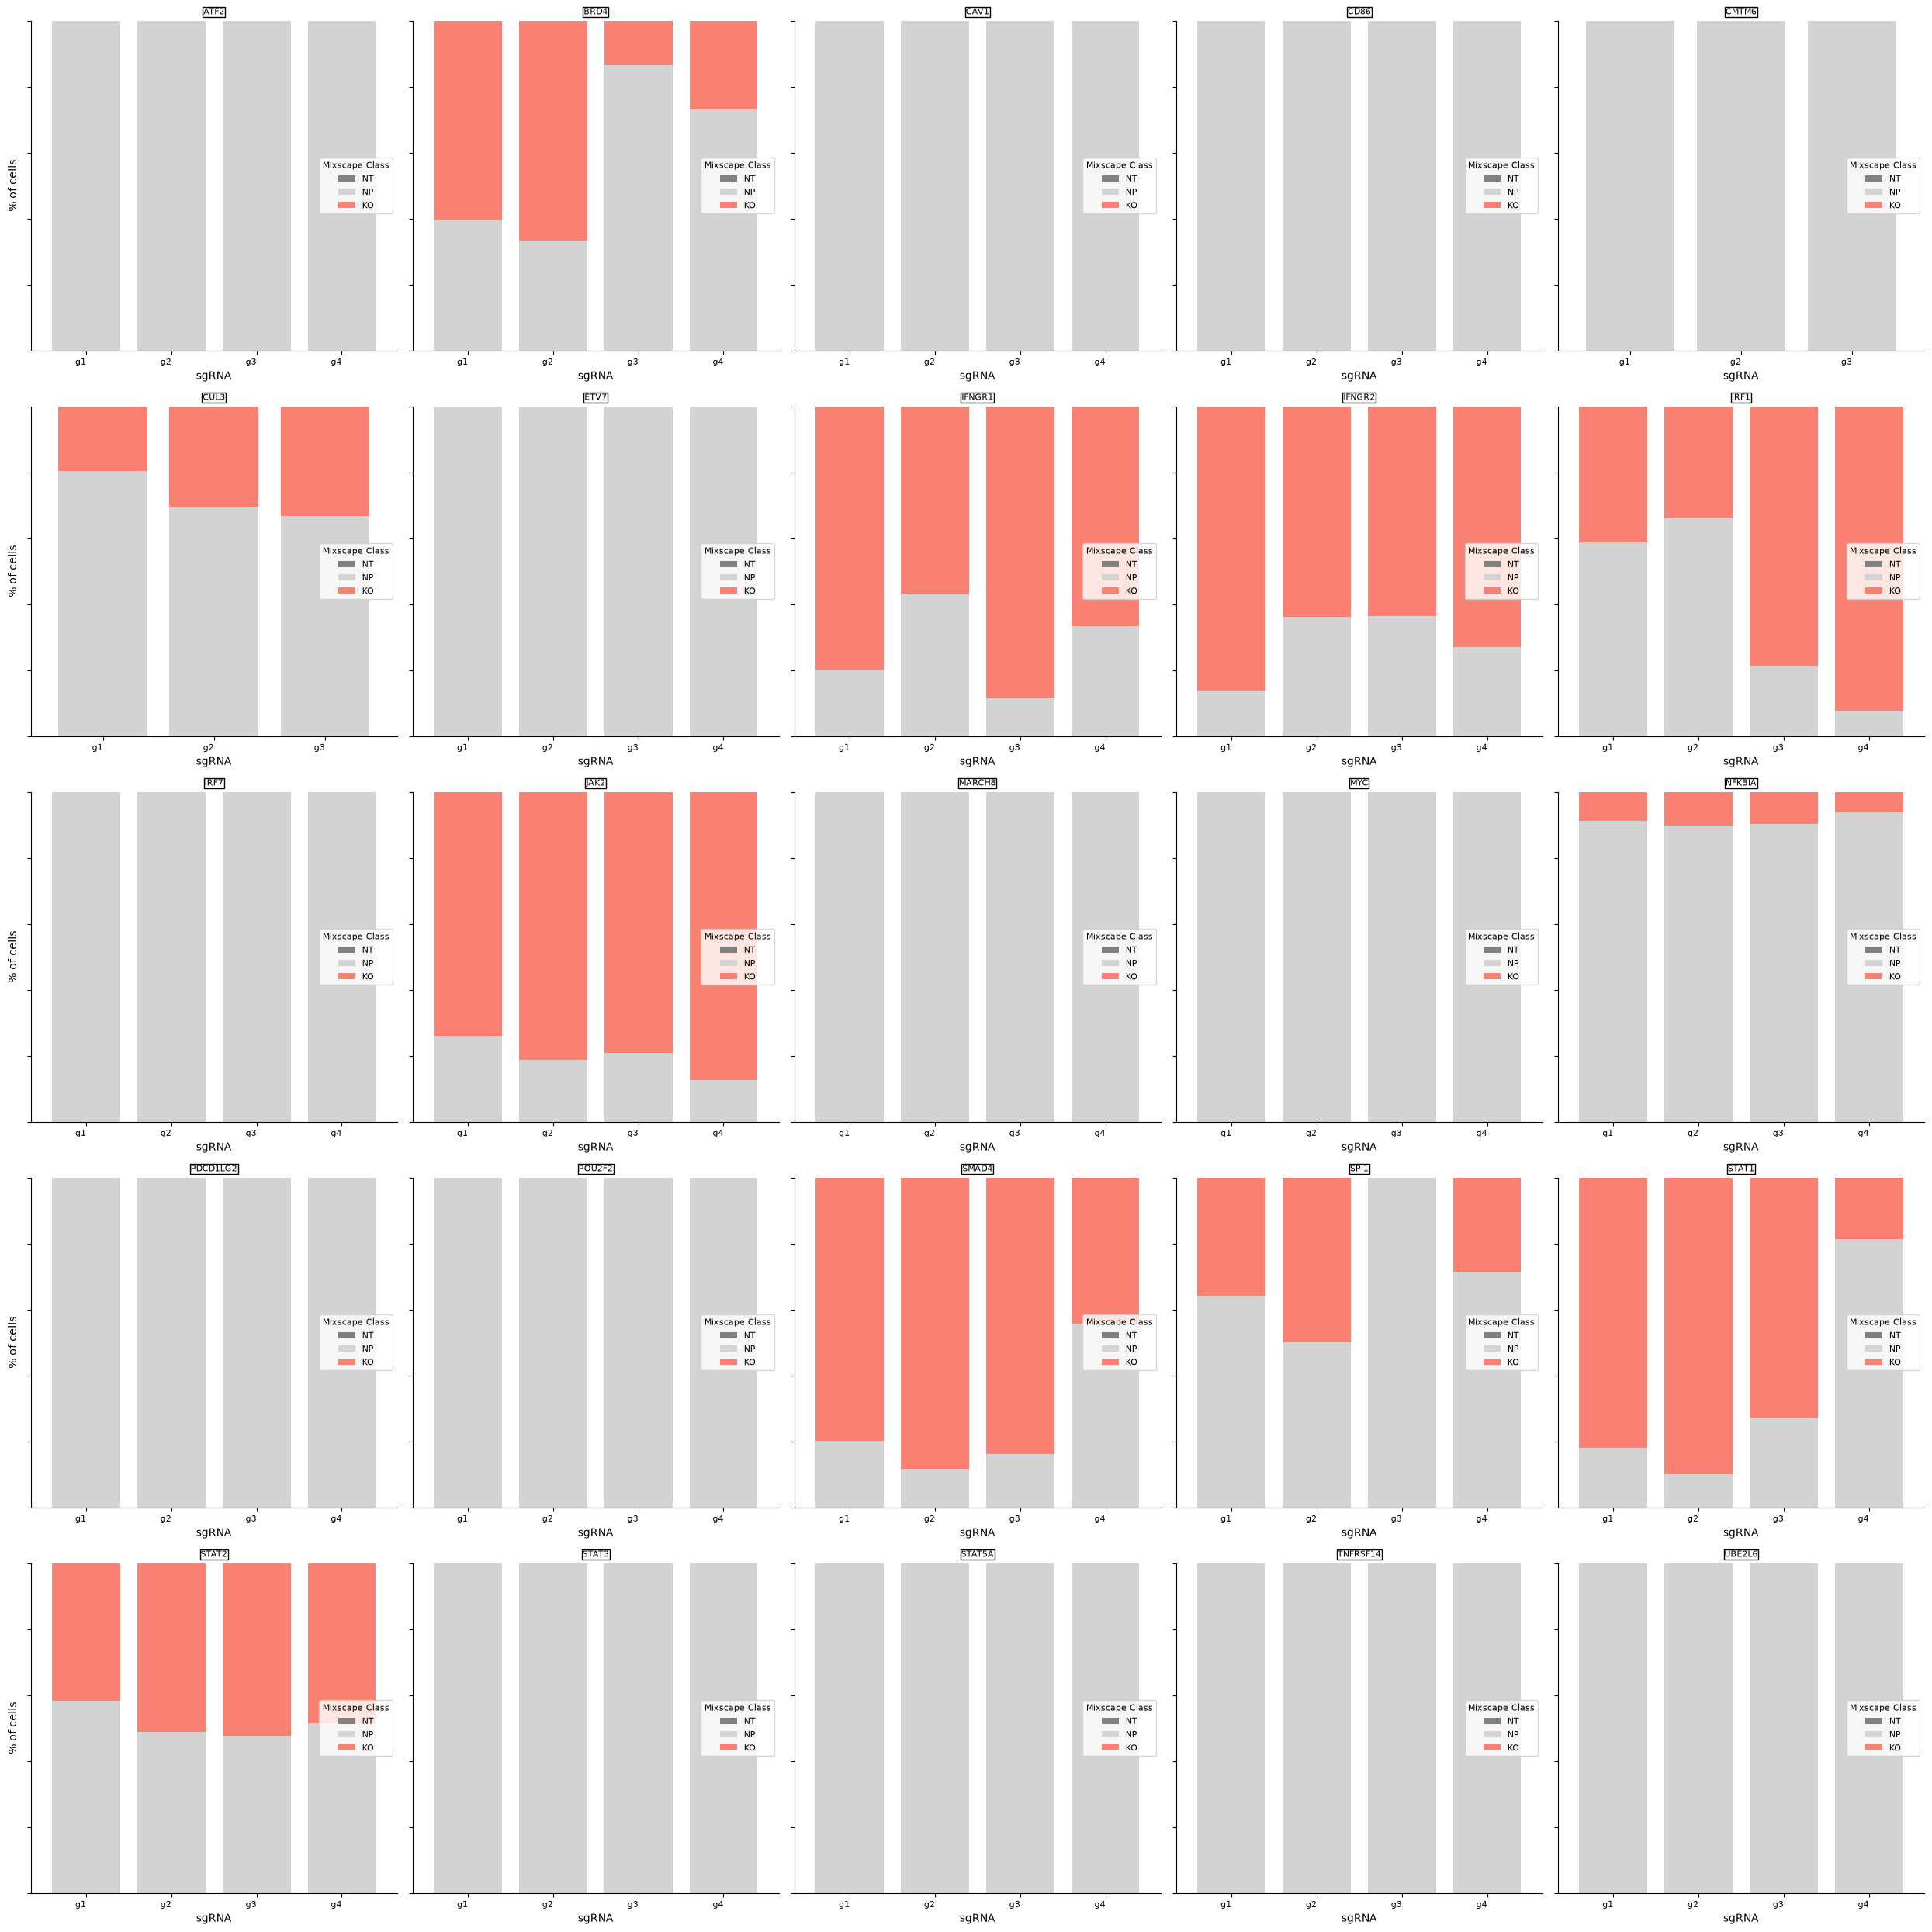

In [37]:
# Identify cells without detectable perturbation
ms.mixscape(adata=mdata["rna"], control="NT", pert_key="gene_target", layer="X_pert")

# detect variation in gRNA targeting efficiency within each class.
ms.plot_barplot(mdata["rna"], guide_rna_column="NT")



## Inspecting mixscape results
To validate that mixscape accurately assigns perturbation status, we can examine the perturbation score distributions and the posterior probabilities of cells in a specific target gene class, like IFNGR2, comparing these with non-targeting (NT) cells. Additionally, we can conduct differential expression (DE) analyses, demonstrating that reduced expression of IFNG-pathway genes is unique to IFNGR2 KO cells. As an independent verification, we can also assess the PD-L1 protein expression levels in non-perturbed (NP) and knockout (KO) cells for genes known to regulate PD-L1.




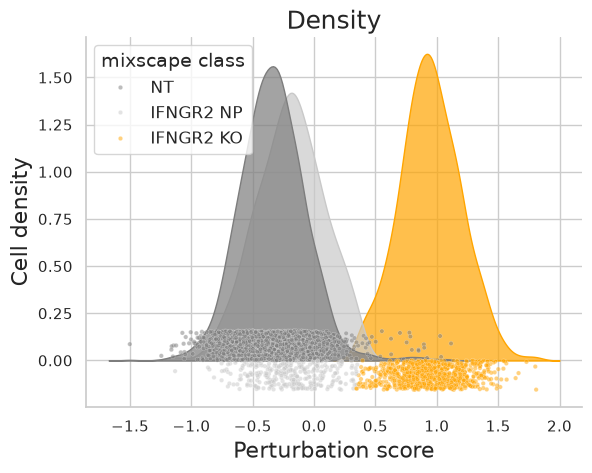

In [38]:
ms.plot_perturbscore(
    adata = mdata["rna"],
    pert_key="gene_target",
    target_gene="IFNGR2",
    color="orange"
)

<ArrowStringArray>
[   'STAT2 KO',     'CAV1 NP',    'STAT1 KO',     'CD86 NP',     'IRF7 NP',
          'NT',     'ATF2 NP',    'STAT3 NP',     'JAK2 NP',   'NFKBIA NP',
    'SMAD4 NP',   'STAT5A NP',    'CMTM6 NP',     'JAK2 KO',   'IFNGR1 NP',
   'UBE2L6 NP', 'PDCD1LG2 NP',   'IFNGR1 KO',     'CUL3 NP',     'BRD4 NP',
   'MARCH8 NP',     'IRF1 KO',   'POU2F2 NP',     'ETV7 NP',     'BRD4 KO',
     'IRF1 NP',   'IFNGR2 NP',    'SMAD4 KO',   'IFNGR2 KO',   'NFKBIA KO',
 'TNFRSF14 NP',    'STAT2 NP',    'STAT1 NP',     'CUL3 KO',     'SPI1 NP',
          'NP',     'SPI1 KO']
Length: 37, dtype: str


/home/limin/.conda/envs/pertpy_v11_env/lib/python3.12/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()
/home/limin/.conda/envs/pertpy_v11_env/lib/python3.12/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()
/home/limin/.conda/envs/pertpy_v11_env/lib/python3.12/site-packages/pertpy/tools/_perturbation_efficacy/_mixscape.py:872: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.stripplot(  # noqa: PLW2901


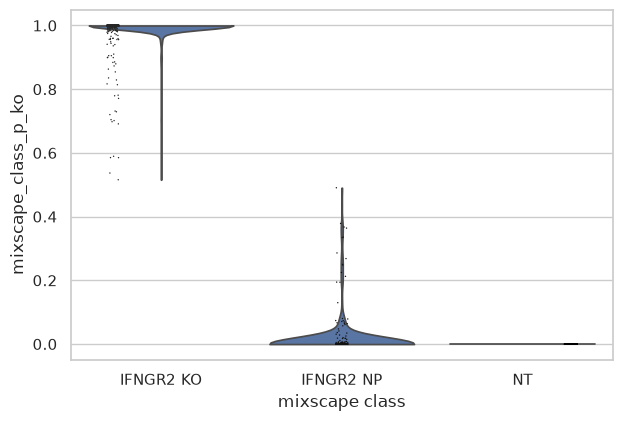

In [39]:
print(mdata["rna"].obs['mixscape_class'].unique())

# Inspect the posterior probability values in NP  and KO cells.
ms.plot_violin(
    adata=mdata["rna"],
    target_gene_idents=["NT", "IFNGR2 NP", "IFNGR2 KO"],
    groupby="mixscape_class",
)


In [40]:
mdata["rna"].obs['gene_target'].unique()

['STAT2', 'CAV1', 'STAT1', 'CD86', 'IRF7', ..., 'ETV7', 'IFNGR2', 'TNFRSF14', 'SPI1', 'MYC']
Length: 26
Categories (26, str): ['ATF2', 'BRD4', 'CAV1', 'CD86', ..., 'STAT3', 'STAT5A', 'TNFRSF14', 'UBE2L6']

categories: IFNGR2 KO, IFNGR2 NP, NT
var_group_labels: NT


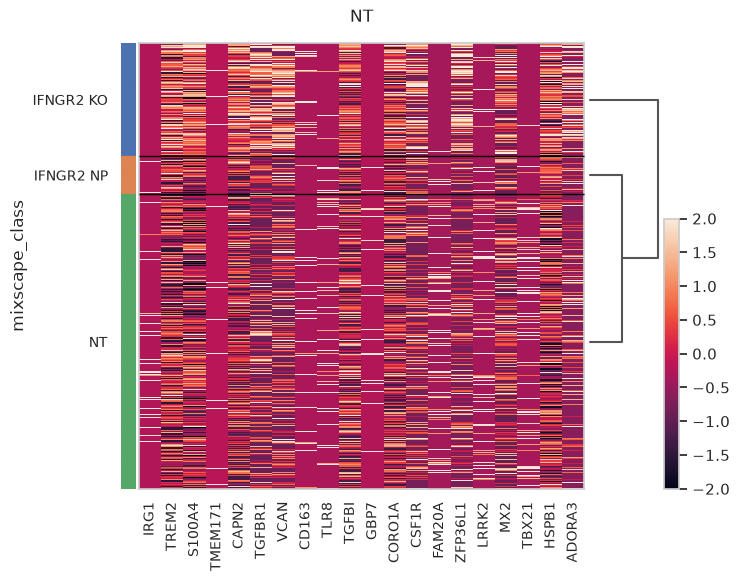

In [41]:
# Run DE analysis and visualize results on a heatmap ordering cells by their posterior probability values.
ms.plot_heatmap(
    adata=mdata["rna"],
    pert_key = "gene_target",
    target_gene="IFNGR2",
    layer="X_pert",
    control="NT",
)




/home/limin/.conda/envs/pertpy_v11_env/lib/python3.12/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


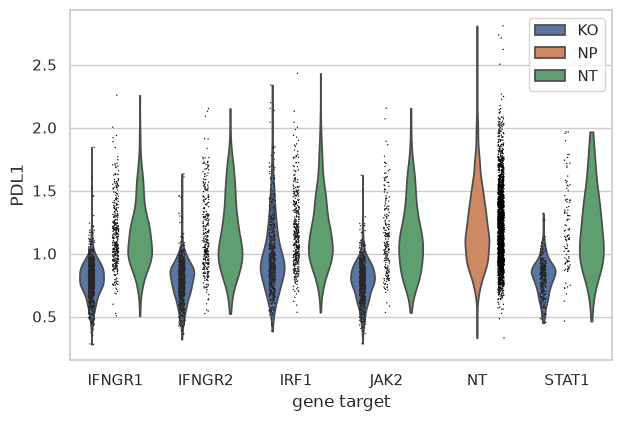

In [42]:
# Show that only IFNG pathway KO cells have a reduction in PD-L1 protein expression.
mdata["adt"].obs["mixscape_class_global"] = mdata["rna"].obs["mixscape_class_global"]
ms.plot_violin(
    adata=mdata["adt"],
    target_gene_idents=["NT", "JAK2", "STAT1", "IFNGR1", "IFNGR2", "IRF1"],
    keys="PDL1",
    groupby="gene_target",
    hue="mixscape_class_global",
)




## Visualizing perturbation responses with Linear Discriminant Analysis (LDA)

Finally, we use LDA as a dimensionality reduction method to visualize perturbation-specific clusters. LDA tries to maximize the separability of known labels (mixscape classes) using both gene expression and the labels as input.

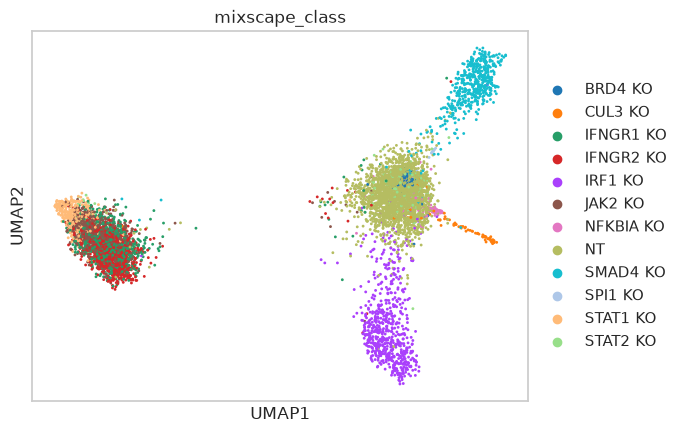

In [43]:
ms = pt.tl.Mixscape()
ms.lda(adata=mdata["rna"], control="NT", pert_key="gene_target", layer="X_pert")

ms.plot_lda(adata=mdata["rna"], control="NT")


## Mixscale: scoring perturbation strength
While Mixscape gives a binary call, many screens, especially CRISPRi and CRISPRa, produce a gradient of perturbation strengths rather than a clean on/off effect. Mixscale instead assigns a continuous per-cell perturbation score [JDP+25]. The score is the projection of each cell’s perturbation signature onto the perturbation direction vector, standardized against the non-targeting control cells. It reuses the same perturbation signature and differential expression steps, so we can run it directly on the object we already prepared.



In [46]:
msc = pt.tl.Mixscale()
msc.mixscale(mdata["rna"], "gene_target", "NT", layer="X_pert")
mdata["rna"].obs[["gene_target", "mixscape_class_global", "mixscale_score"]].head()

,gene_target,mixscape_class_global,mixscale_score
index,,,
l1_AAACCTGAGCCAGAAC,STAT2,KO,4.45586
l1_AAACCTGAGTGGACGT,CAV1,NP,1.00000
l1_AAACCTGCATGAGCGA,STAT1,KO,5.58202
l1_AAACCTGTCTTGTCAT,CD86,NP,1.00000
l1_AAACGGGAGAACAACT,IRF7,NP,1.00000


Non-targeting control cells receive a score of zero by construction. Grouping the cells by their Mixscape call shows that the continuous score recovers the binary classification: the cells labelled KO score far higher than the non-perturbed (NP) and non-targeting (NT) cells.

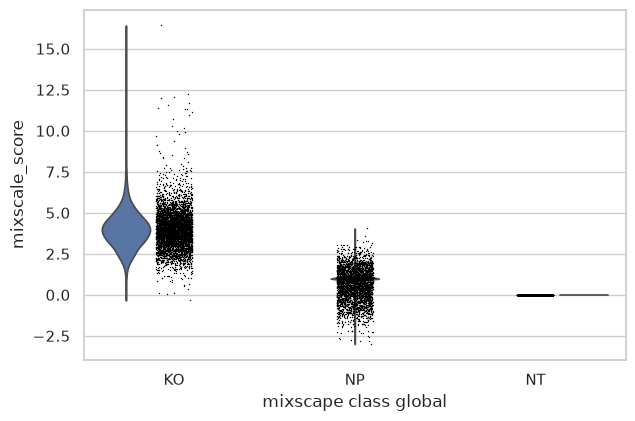

In [47]:
sc.pl.violin(mdata["rna"], keys="mixscale_score", groupby="mixscape_class_global")

The score additionally resolves heterogeneity that the binary call collapses. Focusing on IFNGR2, the non-targeting controls sit at zero and the NP cells stay low, while the KO cells span a broad range of response strengths rather than a single value.

<Axes: xlabel='mixscape_class', ylabel='mixscale_score'>

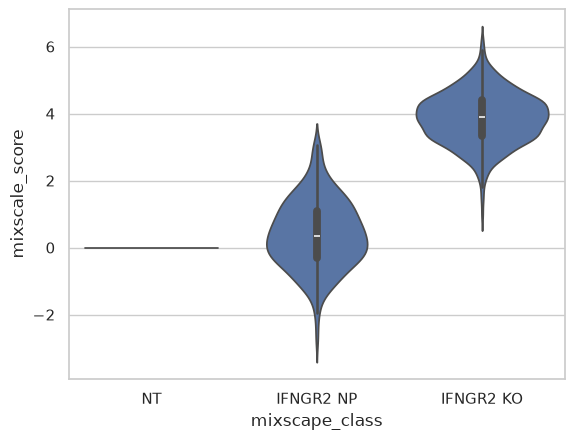

In [48]:
import seaborn as sns

obs = mdata["rna"].obs
ifngr2 = obs[obs["mixscape_class"].isin(["NT", "IFNGR2 NP", "IFNGR2 KO"])]
sns.violinplot(data=ifngr2, x="mixscape_class", y="mixscale_score", order=["NT", "IFNGR2 NP", "IFNGR2 KO"])

Projected onto the perturbation-signature embedding, the score reveals a continuous gradient of response strength where Mixscape draws a hard perturbed/non-perturbed boundary.

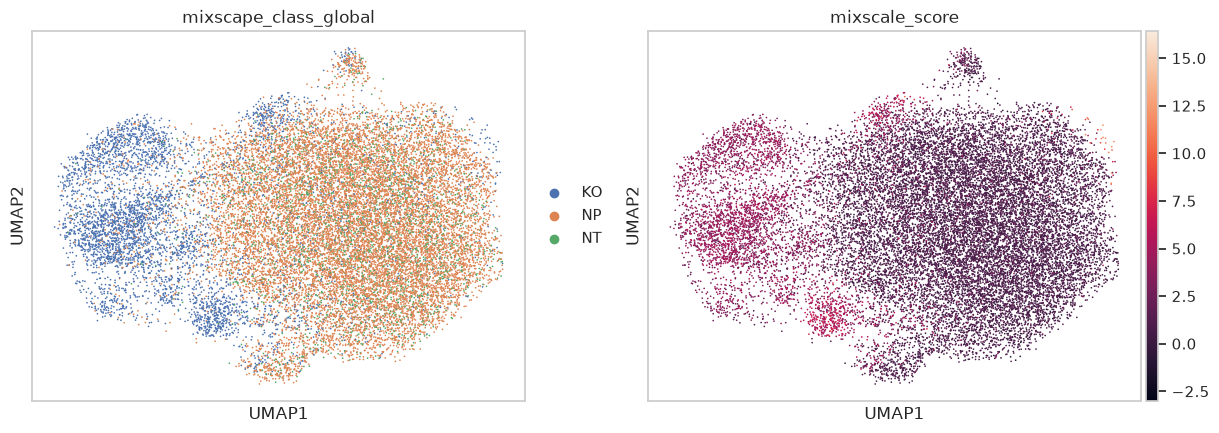

In [49]:
adata_pert.obs["mixscape_class_global"] = mdata["rna"].obs["mixscape_class_global"]
adata_pert.obs["mixscale_score"] = mdata["rna"].obs["mixscale_score"]
sc.pl.umap(adata_pert, color=["mixscape_class_global", "mixscale_score"])

Aggregated per target gene, the score summarises how strongly each perturbation acted across the cells that received it. The non-targeting controls remain at zero, while the spread of each target gene exposes the variation in perturbation efficacy between genes.

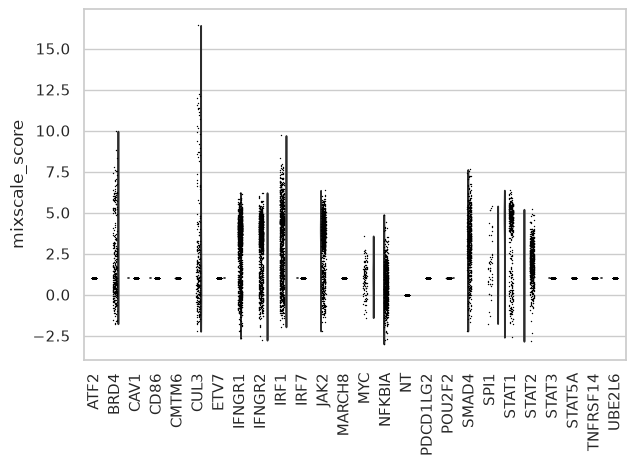

In [50]:
sc.pl.violin(mdata["rna"], keys="mixscale_score", groupby="gene_target", rotation=90)